In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO

# 데이터
data = """Participant\tReal Acc. (%)\tFake Acc. (%)\tOverall Acc. (%)\tFooling Rate (%)
R1\t56.0\t62.0\t59.0\t38.0
R2\t42.0\t48.0\t45.0\t52.0
R3\t36.0\t88.0\t62.0\t12.0
R4\t40.0\t52.0\t46.0\t48.0
R5\t82.0\t84.0\t83.0\t16.0
R6\t38.0\t36.0\t37.0\t64.0"""

df = pd.read_csv(StringIO(data), sep='\t')
print(df)

  Participant  Real Acc. (%)  Fake Acc. (%)  Overall Acc. (%)  \
0          R1           56.0           62.0              59.0   
1          R2           42.0           48.0              45.0   
2          R3           36.0           88.0              62.0   
3          R4           40.0           52.0              46.0   
4          R5           82.0           84.0              83.0   
5          R6           38.0           36.0              37.0   

   Fooling Rate (%)  
0              38.0  
1              52.0  
2              12.0  
3              48.0  
4              16.0  
5              64.0  


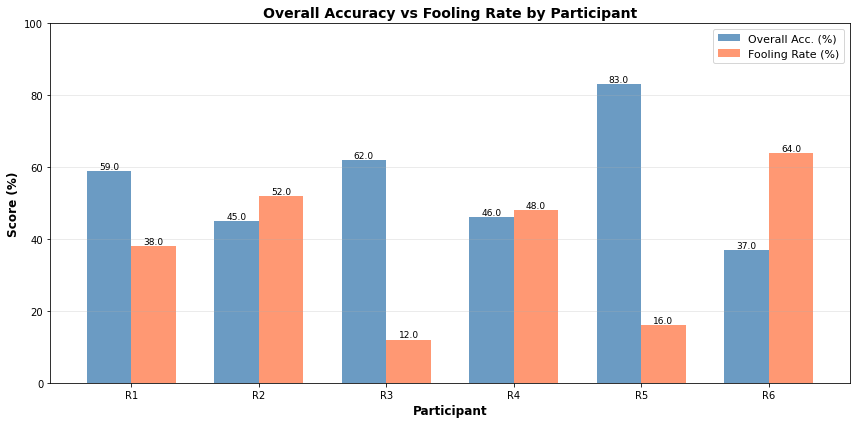

In [2]:
# Overall Acc와 Fooling Rate 그래프
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df))
width = 0.35

bars1 = ax.bar(x - width/2, df['Overall Acc. (%)'], width, label='Overall Acc. (%)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, df['Fooling Rate (%)'], width, label='Fooling Rate (%)', color='coral', alpha=0.8)

ax.set_xlabel('Participant', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Overall Accuracy vs Fooling Rate by Participant', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['Participant'])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

# 각 막대 위에 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

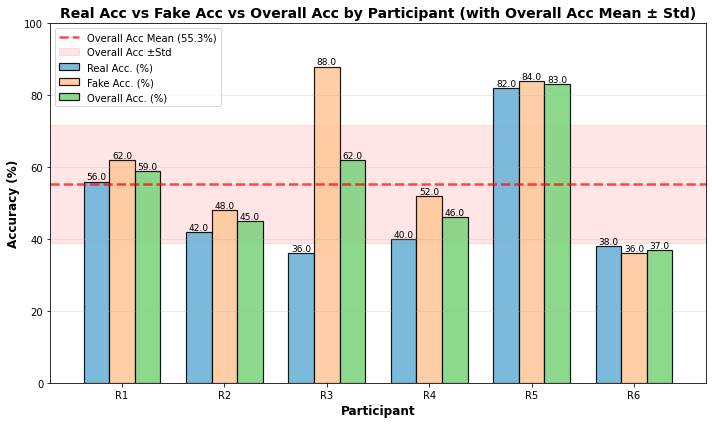


=== 통계 요약 (Overall Acc) ===

Mean: 55.33%
Std: 16.45%
Mean - Std: 38.88%
Mean + Std: 71.79%


In [11]:
# 참가자별 Real Acc, Fake Acc, Overall Acc 그래프 (Overall Acc Mean ± Std 표시)
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df))
width = 0.25

# 파스텔 톤 색상과 검정 테두리 (더 진한 톤)
bars1 = ax.bar(x - width, df['Real Acc. (%)'], width, label='Real Acc. (%)', color='#6DB3D8', edgecolor='black', linewidth=1.2, alpha=0.9)
bars2 = ax.bar(x, df['Fake Acc. (%)'], width, label='Fake Acc. (%)', color='#FFC99C', edgecolor='black', linewidth=1.2, alpha=0.9)
bars3 = ax.bar(x + width, df['Overall Acc. (%)'], width, label='Overall Acc. (%)', color='#80D480', edgecolor='black', linewidth=1.2, alpha=0.9)

# 통계 계산 (Overall Acc만)
stats_data = df[['Real Acc. (%)', 'Fake Acc. (%)', 'Overall Acc. (%)']].copy()
overall_mean = stats_data['Overall Acc. (%)'].mean()
overall_std = stats_data['Overall Acc. (%)'].std()

# 그래프 범위 설정
ax.set_xlim(-0.7, len(df)-0.3)

# Overall Acc Mean 선과 Std 영역 표시 (빨간색 계열)
ax.axhline(y=overall_mean, color='red', linestyle='--', linewidth=2.5, alpha=0.7, label=f'Overall Acc Mean ({overall_mean:.1f}%)')
ax.fill_between([-0.7, len(df)-0.3], overall_mean - overall_std, overall_mean + overall_std, 
                 color='red', alpha=0.1, label=f'Overall Acc ±Std')

ax.set_xlabel('Participant', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Real Acc vs Fake Acc vs Overall Acc by Participant (with Overall Acc Mean ± Std)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['Participant'])
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

# 각 막대 위에 값 표시
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 상세 통계 출력
print("\n=== 통계 요약 (Overall Acc) ===\n")
print(f"Mean: {overall_mean:.2f}%")
print(f"Std: {overall_std:.2f}%")
print(f"Mean - Std: {overall_mean - overall_std:.2f}%")
print(f"Mean + Std: {overall_mean + overall_std:.2f}%")

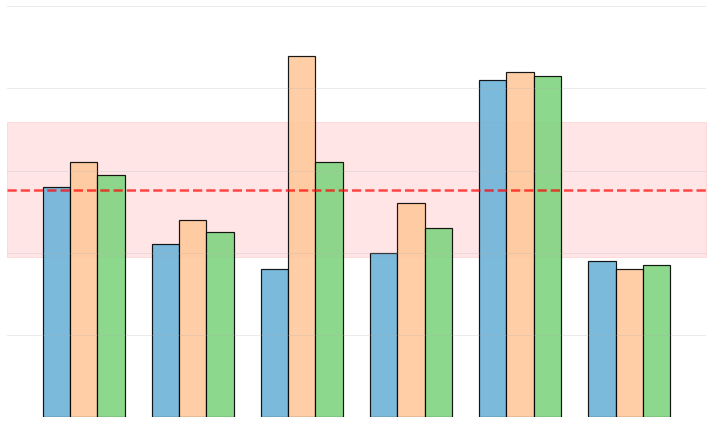

In [19]:
# 그래프만 표시 (Title, Label, Legend, 축 테두리 제거 / 막대 테두리 유지)
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df))
width = 0.25

# 파스텔 톤 색상 + 막대 테두리 유지
bars1 = ax.bar(x - width, df['Real Acc. (%)'], width, color='#6DB3D8', edgecolor='black', linewidth=1.2, alpha=0.9)
bars2 = ax.bar(x, df['Fake Acc. (%)'], width, color='#FFC99C', edgecolor='black', linewidth=1.2, alpha=0.9)
bars3 = ax.bar(x + width, df['Overall Acc. (%)'], width, color='#80D480', edgecolor='black', linewidth=1.2, alpha=0.9)

# 통계 계산 (Overall Acc만)
stats_data = df[['Real Acc. (%)', 'Fake Acc. (%)', 'Overall Acc. (%)']].copy()
overall_mean = stats_data['Overall Acc. (%)'].mean()
overall_std = stats_data['Overall Acc. (%)'].std()

# 그래프 범위 설정
ax.set_xlim(-0.7, len(df)-0.3)

# Overall Acc Mean 선과 Std 영역 표시 (빨간색 계열)
ax.axhline(y=overall_mean, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax.fill_between([-0.7, len(df)-0.3], overall_mean - overall_std, overall_mean + overall_std, 
                 color='red', alpha=0.1)

# Label, Title, Tick 라벨 제거
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(left=False, bottom=False)

# 전체 그래프 축 테두리(spines) 제거
for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()